<a href="https://colab.research.google.com/github/VarsanJ/Cities-in-Motion-2026/blob/main/CatBoostModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0:	learn: 2.1104668	total: 24.8ms	remaining: 24.8s
50:	learn: 1.2946571	total: 970ms	remaining: 18s
100:	learn: 1.1784308	total: 1.9s	remaining: 16.9s
150:	learn: 1.1023103	total: 3.27s	remaining: 18.4s
200:	learn: 1.0397241	total: 4.29s	remaining: 17s
250:	learn: 0.9782700	total: 5.35s	remaining: 16s
300:	learn: 0.9269835	total: 6.97s	remaining: 16.2s
350:	learn: 0.8826040	total: 10.6s	remaining: 19.6s
400:	learn: 0.8394527	total: 12.8s	remaining: 19.1s
450:	learn: 0.7995826	total: 14.8s	remaining: 18s
500:	learn: 0.7613134	total: 16.6s	remaining: 16.5s
550:	learn: 0.7249320	total: 17.5s	remaining: 14.3s
600:	learn: 0.6925230	total: 18.4s	remaining: 12.2s
650:	learn: 0.6635672	total: 19.4s	remaining: 10.4s
700:	learn: 0.6331565	total: 20.4s	remaining: 8.69s
750:	learn: 0.6031835	total: 23.1s	remaining: 7.64s
800:	learn: 0.5763683	total: 24.3s	remaining: 6.04s
850:	learn: 0.5510971	total: 25.2s	remaining: 4.42s
900:	learn: 0.5285762	total: 26.2s	remaining: 2.87s
950:	learn: 0.5084530	t

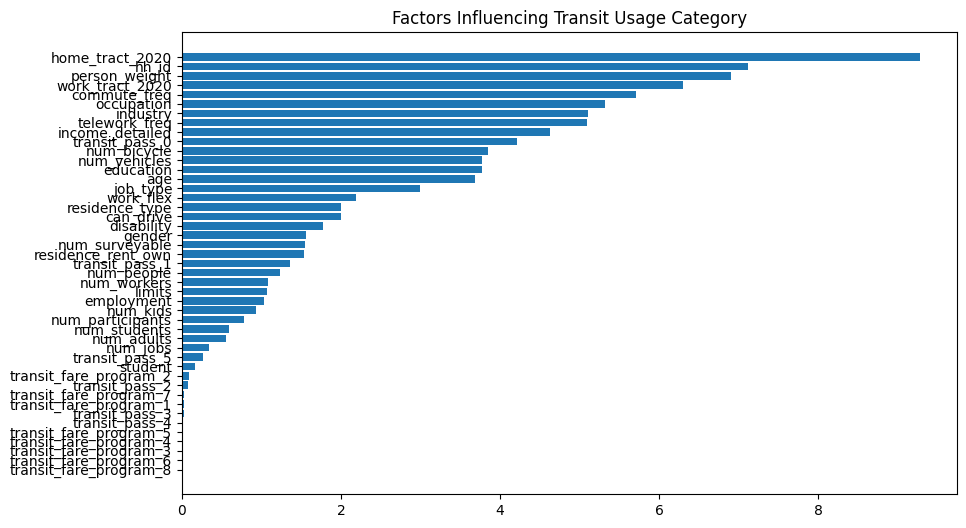


--- SHAP Summary Plot ---


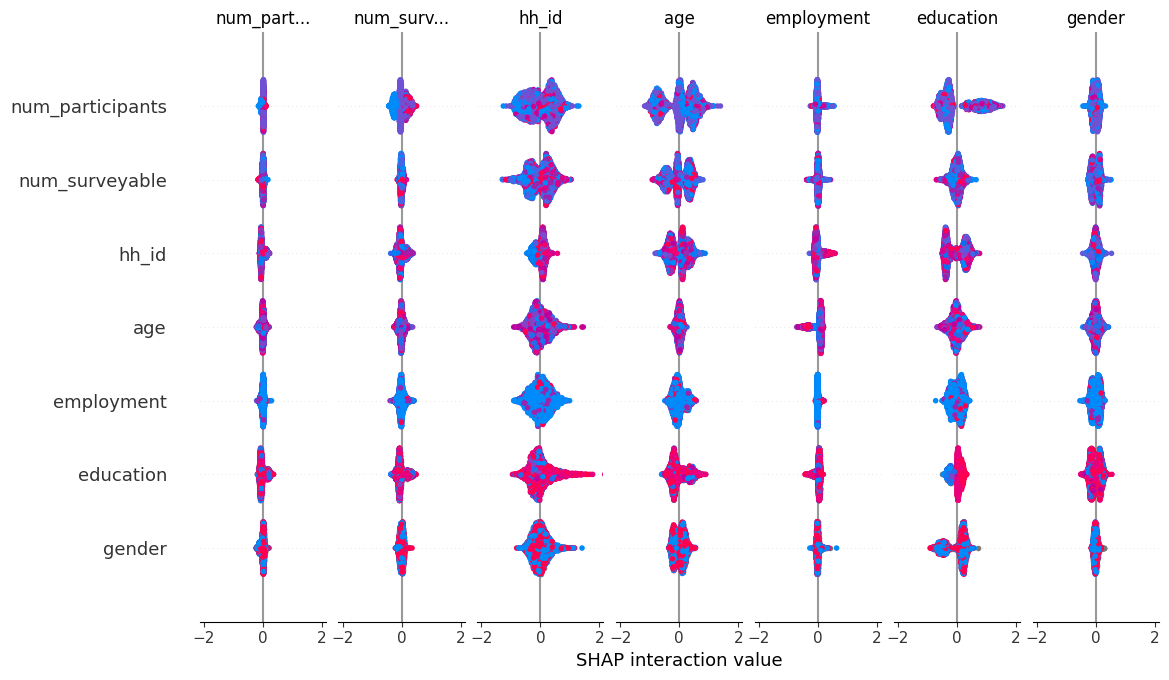


--- Partial Dependence for telework_freq ---


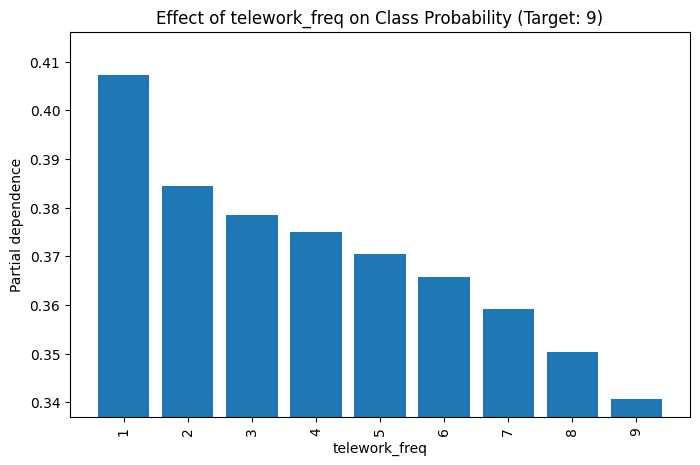

In [10]:
!pip install catboost shap -q

# Imports
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# File Import
fileImport = pd.read_csv("CMAP_NeededVariables.csv")

# Define The Dependent and Independent Variable so far
dependent_var = 'transit_freq'
independent_var = 'telework_freq'

# Handle Special Code Cases in a copy
fileImport_cleaned = fileImport.copy()
# Replace the 996 with 9 (Never)
fileImport_cleaned[dependent_var] = fileImport_cleaned[dependent_var].replace(996, 9)
# General custom codes for invalid responses
custom_codes = [995, 997, 998, 999, -1]
fileImport_cleaned = fileImport_cleaned.replace(custom_codes, np.nan)

fileImport_cleaned[independent_var] = fileImport_cleaned[independent_var].replace(
    [995, 996, 997, 998, 999, -1], np.nan
)

# Cleans variables
df = fileImport_cleaned.dropna(subset=[dependent_var]) # Can't train on NaN targets
X = df.drop(columns=[dependent_var])
y = df[dependent_var]

# Categorical Columns
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create Classification Model
model = CatBoostClassifier(
    iterations=1000, #
    learning_rate=0.05, #
    depth=6, #
    loss_function='MultiClass', # Use MultiClass for categorical frequency levels
    random_seed=42,
    nan_mode='Min', #
    verbose=50 # Print outputs on occasional basis #
)

# Model Training
model.fit(X, y, cat_features=cat_features)

# These graphs were asked by Masoud, some AI Generated below

# Feature Importance Plot
print("\n--- Feature Importance ---")
importance = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature Id'][::-1], importance['Importances'][::-1])
plt.title("Factors Influencing Transit Usage Category")
plt.show()

# SHAP Value Summary Plot
print("\n--- SHAP Summary Plot ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

# Partial Dependence Plot
print(f"\n--- Partial Dependence for {independent_var} ---")

fig, ax = plt.subplots(figsize=(8, 5))

most_frequent_class = y.mode()[0]

PartialDependenceDisplay.from_estimator(
    model,
    X,
    features=[independent_var],
    target=most_frequent_class,
    categorical_features=[independent_var],
    ax=ax
)
# Define graph properties
plt.title(f'Effect of {independent_var} on Class Probability (Target: {most_frequent_class})')
plt.xticks(range(1, 10))
plt.show()